In [781]:
import pandas as pd

In [782]:
# read the dataset
df=pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [783]:
#Task4: rows and columns in dataset
print(df.shape)

(7043, 21)


In [784]:
# shows the type of each column
print(df.dtypes)

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [785]:
# Task:6 6.	Pick 3 categorical columns and report their unique values — do any contain unexpected or inconsistent categories?
print(df["Contract"].unique())
print(df["InternetService"].unique())
print(df["PaymentMethod"].unique())

['Month-to-month' 'One year' 'Two year']
['DSL' 'Fiber optic' 'No']
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


In [786]:
# Task 7: Report missing values (count)
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [787]:
# Task 7: Report missing values (percentage)
print(df.isnull().mean()*100)

customerID          0.0
gender              0.0
SeniorCitizen       0.0
Partner             0.0
Dependents          0.0
tenure              0.0
PhoneService        0.0
MultipleLines       0.0
InternetService     0.0
OnlineSecurity      0.0
OnlineBackup        0.0
DeviceProtection    0.0
TechSupport         0.0
StreamingTV         0.0
StreamingMovies     0.0
Contract            0.0
PaperlessBilling    0.0
PaymentMethod       0.0
MonthlyCharges      0.0
TotalCharges        0.0
Churn               0.0
dtype: float64


In [788]:
# Task:8.Check for duplicate rows and duplicate customer IDs separately — are they the same issue or different issues?
df.duplicated().sum()

np.int64(0)

In [789]:
# Task:8 customer IDs separately
df["customerID"].duplicated().sum()

np.int64(0)

In [790]:
# Task9: Find at least one column with a suspicious, invalid, or inconsistently formatted value, and describe how you found it.
df["TotalCharges"].value_counts()

TotalCharges
20.2      11
          11
19.75      9
19.65      8
19.9       8
          ..
1990.5     1
7362.9     1
346.45     1
306.6      1
108.15     1
Name: count, Length: 6531, dtype: int64

In [791]:
print(df[pd.to_numeric(df["TotalCharges"],errors="coerce").isnull()]["TotalCharges"])

488      
753      
936      
1082     
1340     
3331     
3826     
4380     
5218     
6670     
6754     
Name: TotalCharges, dtype: object


In [792]:
# Task  11: Apply cleaning decisions
clean_df=df.copy()
clean_df["TotalCharges"]=pd.to_numeric(clean_df["TotalCharges"],errors="coerce")

In [793]:
print(clean_df["TotalCharges"].dtype)

float64


In [794]:
print(clean_df["TotalCharges"].isnull().sum())

11


In [795]:
print(clean_df.loc[clean_df["TotalCharges"].isnull(),["tenure","TotalCharges","Churn"]])

      tenure  TotalCharges Churn
488        0           NaN    No
753        0           NaN    No
936        0           NaN    No
1082       0           NaN    No
1340       0           NaN    No
3331       0           NaN    No
3826       0           NaN    No
4380       0           NaN    No
5218       0           NaN    No
6670       0           NaN    No
6754       0           NaN    No


In [796]:
clean_df["TotalCharges"]=clean_df["TotalCharges"].fillna(0)

In [797]:
print(clean_df["TotalCharges"].isnull().sum())

0


In [798]:
clean_df=clean_df.drop(columns=["customerID"])

In [799]:
print(clean_df.isnull().sum())

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [800]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


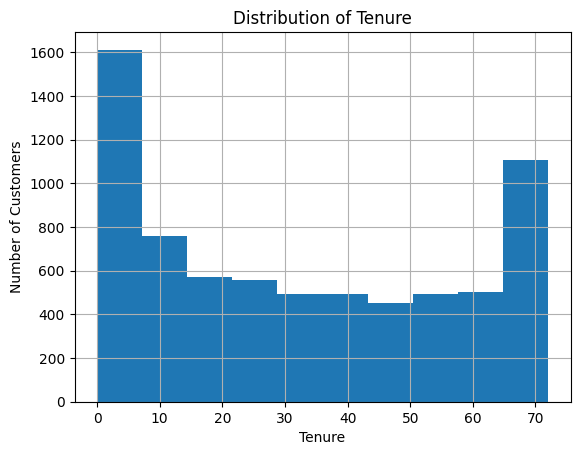

In [ ]:
# Task12: Visualize numerical feature - Tenure
import matplotlib.pyplot as plt
clean_df["tenure"].hist()
plt.xlabel("Tenure")
plt.ylabel("Number of Customers")
plt.title("Distribution of Tenure")
plt.show()

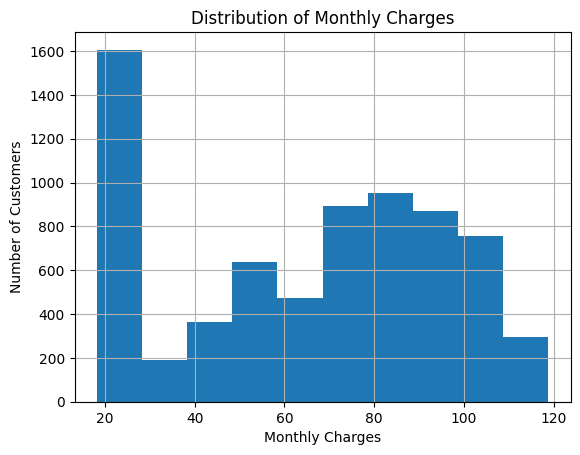

In [811]:
# Task 12: Visualize numerical feature - MonthlyCharges
clean_df["MonthlyCharges"].hist()
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")
plt.title("Distribution of Monthly Charges")
plt.show()

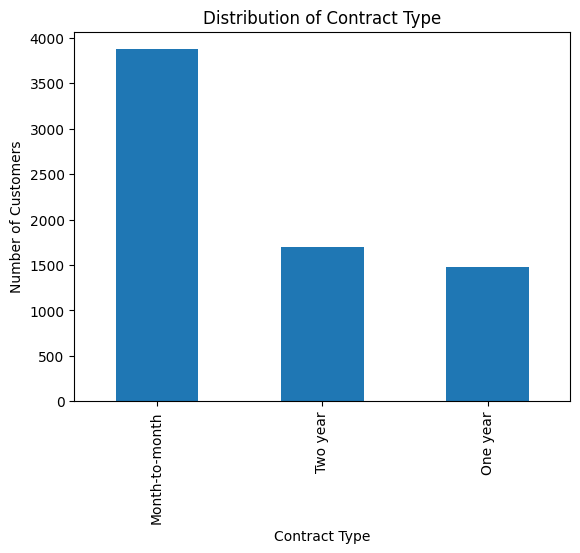

In [821]:
# Task 12: Visualize categorical feature - Contract
clean_df["Contract"].value_counts().plot(kind="bar")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.title("Distribution of Contract Type")
plt.show()

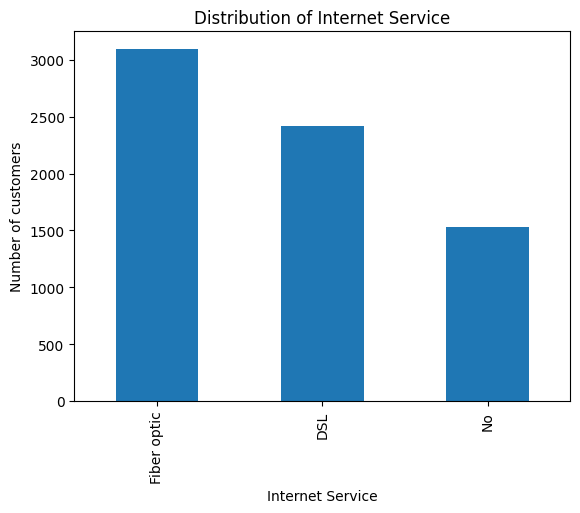

In [ ]:
# Task 12: Visualize categorical feature - InternetService
import matplotlib.pyplot as plt
clean_df["InternetService"].value_counts().plot(kind="bar")
plt.xlabel("Internet Service")
plt.ylabel("Number of customers")
plt.title("Distribution of Internet Service")
plt.show()

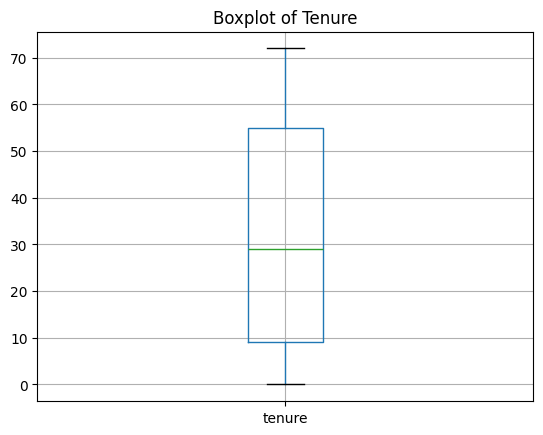

In [ ]:

#Task13: Check outliers in tenure
clean_df.boxplot(column="tenure")
plt.title("Boxplot of Tenure")
plt.show()

In [ ]:
#Task14: Count churned and non-churned customers
print(clean_df["Churn"].value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [ ]:
#Task14: Calculate churn percentages
print(clean_df["Churn"].value_counts(normalize=True)*100)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [ ]:
#Task16: Contract vs Churn
print(pd.crosstab(clean_df["InternetService"],clean_df["Churn"],normalize="index")*100)

Churn                   No        Yes
InternetService                      
DSL              81.040892  18.959108
Fiber optic      58.107235  41.892765
No               92.595020   7.404980


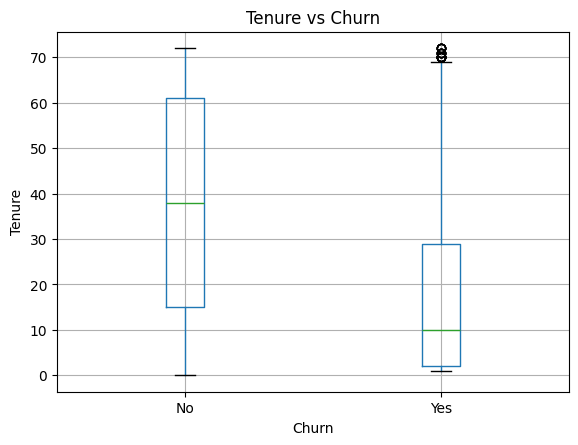

In [839]:
#Task17:Tenure vs Churn
clean_df.boxplot(column="tenure",by="Churn")
plt.title("Tenure vs Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Tenure")
plt.show()

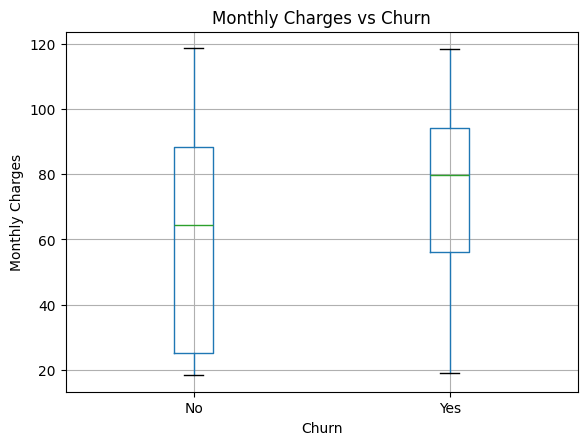

In [840]:
#Task17:MonthlyCharges vs Churn
clean_df.boxplot(column="MonthlyCharges",by="Churn")
plt.title("Monthly Charges vs Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

In [ ]:
#Task18: Calculate correlation matrix
corr_matrix=clean_df.corr(numeric_only=True)
print(corr_matrix)

                SeniorCitizen    tenure  MonthlyCharges  TotalCharges
SeniorCitizen        1.000000  0.016567        0.220173      0.103006
tenure               0.016567  1.000000        0.247900      0.826178
MonthlyCharges       0.220173  0.247900        1.000000      0.651174
TotalCharges         0.103006  0.826178        0.651174      1.000000


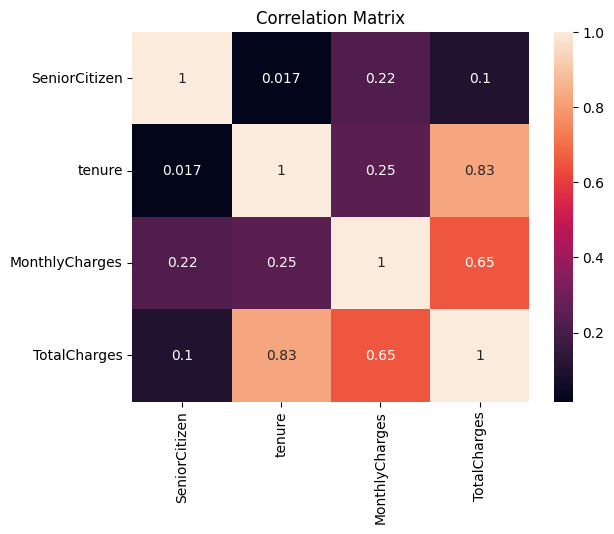

In [ ]:
#Task18:x`x`Visualize correlation matrix
import seaborn as sns
sns.heatmap(corr_matrix,annot=True)
plt.title("Correlation Matrix")
plt.show()

In [845]:
#Task20:Inspect columns for data leakage
print(clean_df.columns)

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


In [846]:
clean_df.to_csv("clean_churn.csv",index=False)

In [847]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 
